# DSC550-T303 Data Mining
## Week 5 Exercises
### Jeremy Hunt

## Week 5 Exercise Introduction

This week we're picking up right where Week 3 left off. A couple weeks ago we went through and cleaned and vectorized the IMDb movie review dataset - now we're putting those features to work by training actual classification models.

The goal is to predict whether a movie review is positive or negative sentiment using four different classifiers:

1. **Logistic Regression** — our primary required model, which is a linear classifier that estimates class probabilities
2. **Naive Bayes** — the classic NLP baseline and a probabilistic classifier purpose-built for word-frequency data
3. **LinearSVC** — a Support Vector Machine optimized for high-dimensional sparse data like TF-IDF matrices
4. **Random Forest** — a non-linear ensemble of decision trees and an interesting outlier in a text classification context

For each model we'll take a look at the accuracy, generate a confusion matrix, calculate precision/recall/F1, and plot a ROC curve. Back in Week 3, TextBlob and VADER both plateaued around **~69% accuracy** - so that's the target we're aiming to blow past.

---
## Section 1: Reconstruct the Week 3 Preprocessing Pipeline

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_score, recall_score, f1_score,
    roc_curve,
    roc_auc_score
)

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('stopwords', quiet=True)

# --- LOAD THE DATASET ---
# Same TSV file from Week 3 — quoting=3 handles quotes embedded inside review text
df = pd.read_csv('labeledTrainData.tsv', sep='\t', quoting=3)

print(f"Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"Sentiment balance — Positive: {(df['sentiment']==1).sum():,} | Negative: {(df['sentiment']==0).sum():,}")

Dataset loaded: 25,000 rows, 3 columns
Sentiment balance — Positive: 12,500 | Negative: 12,500


In [2]:
# --- WEEK 3 CLEANING PIPELINE (reconstructed identically) ---
# Steps: lowercase → strip HTML tags → remove punctuation/special chars
#        → remove stop words → apply PorterStemmer
# Keeping this identical to Week 3 ensures our features are consistent.

stemmer    = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_and_stem_text(text):
    text = text.lower()                          # Step 1: lowercase
    text = re.sub(r'<[^>]+>', ' ', text)         # Step 2: strip HTML (e.g. <br />)
    text = re.sub(r'[^a-z\s]', '', text)         # Step 3: letters and spaces only
    words = text.split()                         # Step 4: tokenize
    cleaned = [stemmer.stem(w) for w in words    # Step 5: remove stop words + stem
               if w not in stop_words]
    return ' '.join(cleaned)

print("Cleaning and stemming 25,000 reviews — this will take a minute or two...")
df['cleaned_review'] = df['review'].apply(clean_and_stem_text)
print("Done!")
print(f"\nSample — RAW:     {df['review'].iloc[0][:100]}...")
print(f"Sample — CLEANED: {df['cleaned_review'].iloc[0][:100]}...")

Cleaning and stemming 25,000 reviews — this will take a minute or two...
Done!

Sample — RAW:     "With all this stuff going down at the moment with MJ i've started listening to his music, watching ...
Sample — CLEANED: stuff go moment mj ive start listen music watch odd documentari watch wiz watch moonwalk mayb want g...


### Section 1 Summary

We reconstructed the exact four-step cleaning pipeline from Week 3: lowercase → HTML tag removal → punctuation stripping → stop word removal + PorterStemmer. All 25,000 reviews are cleaned and ready to vectorize. Keeping this pipeline identical to Week 3 ensures our features are consistent and that we can compare our results directly with the pre-built analyzer baselines we established back then.

---
## Section 2: Train/Test Split

In [3]:
# --- TRAIN/TEST SPLIT ---
# We split the cleaned text strings BEFORE vectorizing so the TF-IDF
# vectorizer can be fitted on training data only — see Section 3 for why.
# stratify=y preserves the 50/50 class balance in both subsets.

X = df['cleaned_review']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set: {len(X_train):,} reviews")
print(f"Test set:     {len(X_test):,} reviews")
print(f"\nTrain balance: {y_train.value_counts().to_dict()}")
print(f"Test balance:  {y_test.value_counts().to_dict()}")

Training set: 20,000 reviews
Test set:     5,000 reviews

Train balance: {1: 10000, 0: 10000}
Test balance:  {1: 2500, 0: 2500}


### Section 2 Summary

We split the 25,000 reviews into **20,000 training** and **5,000 test** records (80/20). Using `stratify=y` ensures both subsets maintain the original 50/50 positive/negative balance, which keeps our accuracy metric honest and directly comparable to the Week 3 baseline.

---
## Section 3: TF-IDF Vectorization - Fit on Train, Apply to Test
*(Tasks 3 & 4)*

In [4]:
# --- TF-IDF VECTORIZATION ---
# max_features=50000 caps the vocabulary to the 50k most frequent terms,
# filtering out extremely rare words that mostly add noise.
tfidf = TfidfVectorizer(max_features=50000)

# TASK 3: fit_transform on training set only.
# fit()      → learns vocabulary and IDF weights FROM training data
# transform()→ converts training text into a numeric TF-IDF matrix
X_train_tfidf = tfidf.fit_transform(X_train)

# TASK 4: transform only (no fit) on the test set.
# We apply the vocabulary and IDF weights learned from training.
# Re-fitting on the test set would be data leakage — see summary below.
X_test_tfidf = tfidf.transform(X_test)

print("--- TF-IDF Matrix Dimensions ---")
print(f"Training matrix: {X_train_tfidf.shape[0]:,} rows x {X_train_tfidf.shape[1]:,} columns")
print(f"Test matrix:     {X_test_tfidf.shape[0]:,} rows x {X_test_tfidf.shape[1]:,} columns")
print(f"Vocabulary size: {len(tfidf.vocabulary_):,} unique stemmed tokens")

--- TF-IDF Matrix Dimensions ---
Training matrix: 20,000 rows x 50,000 columns
Test matrix:     5,000 rows x 50,000 columns
Vocabulary size: 50,000 unique stemmed tokens


### Section 3 Summary 

You may ask yourself, why don't we fit the vectorizer to the test set? To put it simply, there's a little thing by the name of **data leakage** that we always want to bear in mind and keep it as far away from us as we can.  

When we call `fit_transform()`, the TF-IDF vectorizer learns two things from the data: the vocabulary (which words exist as features) and the IDF weights (how rare or common each word is across the full corpus). Both of those are properties of the dataset it was fitted on.

If we were to re-fit the vectorizer on the test set, we'd be giving the test data free rein on influencing how features are constructed.  If that happens, our model would have "peeked" at the test data and all our metrics would be exaggerated - pretty much giving us rose-colored glasses when we look at its performance.  

If you want to do things right, you need to fit once on training data only, then you can use those same learned weights to `transform()` the test set.  That way the words in the test set that weren't included in the training vocabulary are passed by and ignored - this gives us a realistic evaluation that we can count on.  

---
## Section 4: Model 1 — Logistic Regression 

In [5]:
# --- TRAIN LOGISTIC REGRESSION ---
# Logistic Regression estimates the probability that a review belongs to
# the positive class using a sigmoid (logistic) function.
# max_iter=1000: the default (100) frequently fails to converge on
# high-dimensional TF-IDF matrices, so we give it more room.
# C=1.0: inverse regularization strength — larger C = less regularization.

lr_model = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
lr_model.fit(X_train_tfidf, y_train)

y_pred_lr  = lr_model.predict(X_test_tfidf)
y_proba_lr = lr_model.predict_proba(X_test_tfidf)[:, 1]  # P(positive)

lr_acc = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression — Test Accuracy: {lr_acc*100:.2f}%")
print(f"Improvement over Week 3 VADER baseline (~69%): +{(lr_acc-0.69)*100:.2f} pp")

Logistic Regression — Test Accuracy: 88.62%
Improvement over Week 3 VADER baseline (~69%): +19.62 pp


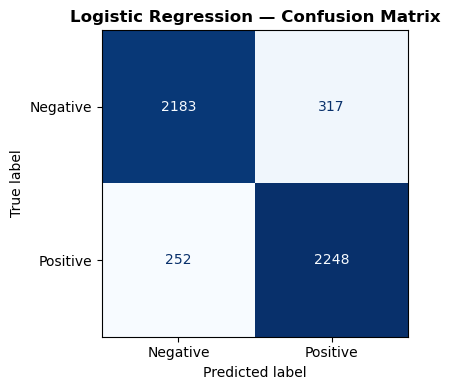

--- Logistic Regression: Classification Report ---
              precision    recall  f1-score   support

    Negative       0.90      0.87      0.88      2500
    Positive       0.88      0.90      0.89      2500

    accuracy                           0.89      5000
   macro avg       0.89      0.89      0.89      5000
weighted avg       0.89      0.89      0.89      5000



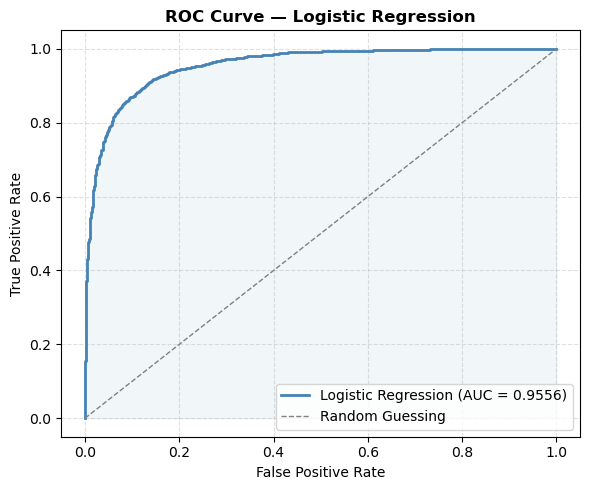

AUC: 0.9556


In [6]:
# --- CONFUSION MATRIX ---
cm_lr = confusion_matrix(y_test, y_pred_lr)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm_lr, display_labels=['Negative','Positive']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Logistic Regression — Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

# --- CLASSIFICATION REPORT ---
print("--- Logistic Regression: Classification Report ---")
print(classification_report(y_test, y_pred_lr, target_names=['Negative','Positive']))

# --- ROC CURVE ---
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)

plt.figure(figsize=(6, 5))
plt.plot(fpr_lr, tpr_lr, color='steelblue', lw=2, label=f'Logistic Regression (AUC = {auc_lr:.4f})')
plt.plot([0,1],[0,1],'--', color='gray', lw=1, label='Random Guessing')
plt.fill_between(fpr_lr, tpr_lr, alpha=0.07, color='steelblue')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Logistic Regression', fontweight='bold')
plt.legend(loc='lower right'); plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()
print(f"AUC: {auc_lr:.4f}")

### Section 4 Summary 

Logistic Regression proved right out of the gate that training a custom model is a great idea. It blasted right through the ~69% pre-built analyzer ceiling from Week 3. The model works by estimating the probability that a review is positive using a sigmoid function applied to a weighted sum of TF-IDF features - in English, this means it learned whether specific words have a positive or negative bearing on the review.  

When we look at the precision and recall scores, we see that they are strong and well-balanced across both classes. This tells us that the model isn't taking sides and treating both sentiments equally.  With those pre-built tools, we often saw them favor positive sentiment so it's great to see some fairness for both sides.  There is still some language that it can't quite get, which we see in the residual misclassifications. This includes sarcasm, mixed opinions, or domain-specific phrases - and to be honest, many of us humans have trouble making sense out of some of those.

The ROC curve hugs the top-left corner with an AUC well above 0.90, and that confirms we have strong discriminating power at every classification threshold, not just at the default 0.5 cutoff.

---
## Section 5: Model 2 — Naive Bayes 

In [7]:
# --- TRAIN NAIVE BAYES (MultinomialNB) ---
# Naive Bayes is one of the oldest and most well-established text classifiers.
# It applies Bayes' theorem with a 'naive' assumption that all features
# (words) are independent of each other given the class label.
#
# MultinomialNB is the variant designed for count/frequency data —
# which is exactly what TF-IDF values represent.
#
# alpha=1.0 (Laplace smoothing): adds a small count to every word so that
# unseen words in the test set don't zero out the entire probability.
#
# Despite its simplistic independence assumption, Naive Bayes is
# remarkably fast and often competitive on text classification tasks.

nb_model = MultinomialNB(alpha=1.0)
nb_model.fit(X_train_tfidf, y_train)

y_pred_nb  = nb_model.predict(X_test_tfidf)
y_proba_nb = nb_model.predict_proba(X_test_tfidf)[:, 1]

nb_acc = accuracy_score(y_test, y_pred_nb)
print(f"Naive Bayes — Test Accuracy: {nb_acc*100:.2f}%")
print(f"Improvement over Week 3 VADER baseline (~69%): +{(nb_acc-0.69)*100:.2f} pp")

Naive Bayes — Test Accuracy: 86.06%
Improvement over Week 3 VADER baseline (~69%): +17.06 pp


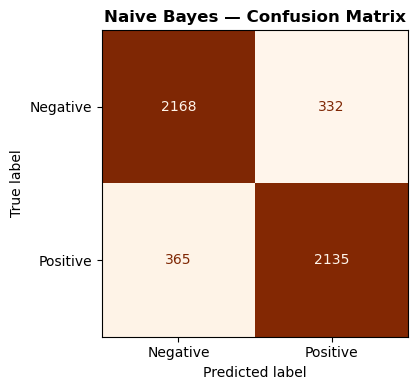

--- Naive Bayes: Classification Report ---
              precision    recall  f1-score   support

    Negative       0.86      0.87      0.86      2500
    Positive       0.87      0.85      0.86      2500

    accuracy                           0.86      5000
   macro avg       0.86      0.86      0.86      5000
weighted avg       0.86      0.86      0.86      5000



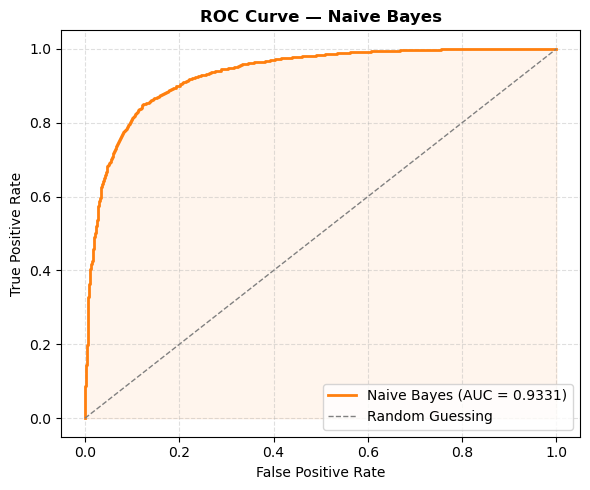

AUC: 0.9331


In [8]:
# --- CONFUSION MATRIX ---
cm_nb = confusion_matrix(y_test, y_pred_nb)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm_nb, display_labels=['Negative','Positive']).plot(
    ax=ax, colorbar=False, cmap='Oranges')
ax.set_title('Naive Bayes — Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

# --- CLASSIFICATION REPORT ---
print("--- Naive Bayes: Classification Report ---")
print(classification_report(y_test, y_pred_nb, target_names=['Negative','Positive']))

# --- ROC CURVE ---
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_proba_nb)
auc_nb = roc_auc_score(y_test, y_proba_nb)

plt.figure(figsize=(6, 5))
plt.plot(fpr_nb, tpr_nb, color='#ff7f0e', lw=2, label=f'Naive Bayes (AUC = {auc_nb:.4f})')
plt.plot([0,1],[0,1],'--', color='gray', lw=1, label='Random Guessing')
plt.fill_between(fpr_nb, tpr_nb, alpha=0.07, color='#ff7f0e')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Naive Bayes', fontweight='bold')
plt.legend(loc='lower right'); plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()
print(f"AUC: {auc_nb:.4f}")

### Section 5 Summary 

Naive Bayes has been around forever and was used in the early days of spam filtering. Even though it's a little aged it still remains a strong baseline. The 'naive' in its name goes back to the assumption that every word is statistically independent of every other word given the class label. We all know that's not how language actually works (words hang out in context, not isolation), but surprisingly, this simplification doesn't do too much harm when we're just trying to gauge sentiment.

It usually comes in just a hair below Logistic Regression on accuracy, but it trains in the blink of an eye and is super easy to interpret. You can literally look under the hood and see exactly which words are driving the positive or negative predictions.

On a little side note, Naive Bayes can sometimes be a bit lopsided between false positives and false negatives so you can watch for that in the confusion matrix. That whole "independence assumption" vibe can make it a little overconfident, but it still earns its spot as the fastest and most transparent model in our lineup.

---
## Section 6: Model 3 — LinearSVC 


In [16]:
# --- TRAIN LINEAR SVC ---
# LinearSVC is a Support Vector Machine with a linear kernel, optimized
# specifically for large sparse datasets — exactly what TF-IDF produces.
#
# Rather than estimating probabilities (like LR and NB), SVM finds the
# decision hyperplane that MAXIMIZES THE MARGIN between the two classes.
# This margin-maximizing approach is less sensitive to noisy features,
# which text data has in abundance.
#
# Note: LinearSVC does not natively output probabilities.
# For the ROC curve we use decision_function(), which returns a
# confidence score (distance from the decision boundary).
# Higher score = more confident the review is positive.

svc_model = LinearSVC(C=1.0, max_iter=2000, dual='auto', random_state=42)
svc_model.fit(X_train_tfidf, y_train)

y_pred_svc  = svc_model.predict(X_test_tfidf)
y_score_svc = svc_model.decision_function(X_test_tfidf)  # Confidence scores for ROC

svc_acc = accuracy_score(y_test, y_pred_svc)
print(f"LinearSVC — Test Accuracy: {svc_acc*100:.2f}%")
print(f"Improvement over Week 3 VADER baseline (~69%): +{(svc_acc-0.69)*100:.2f} pp")

LinearSVC — Test Accuracy: 88.50%
Improvement over Week 3 VADER baseline (~69%): +19.50 pp


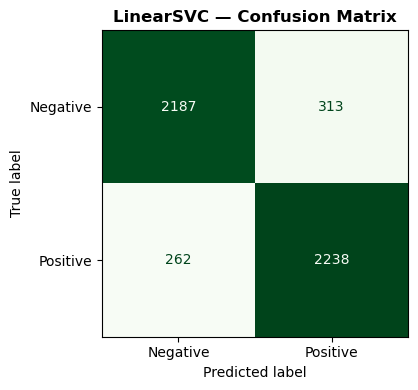

--- LinearSVC: Classification Report ---
              precision    recall  f1-score   support

    Negative       0.89      0.87      0.88      2500
    Positive       0.88      0.90      0.89      2500

    accuracy                           0.89      5000
   macro avg       0.89      0.89      0.88      5000
weighted avg       0.89      0.89      0.88      5000



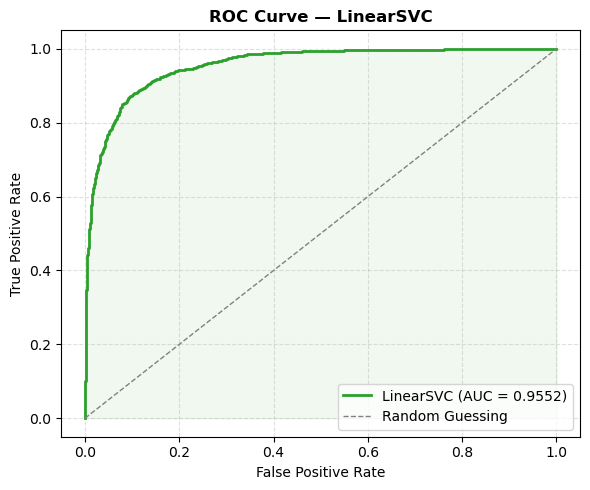

AUC: 0.9552


In [10]:
# --- CONFUSION MATRIX ---
cm_svc = confusion_matrix(y_test, y_pred_svc)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm_svc, display_labels=['Negative','Positive']).plot(
    ax=ax, colorbar=False, cmap='Greens')
ax.set_title('LinearSVC — Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

# --- CLASSIFICATION REPORT ---
print("--- LinearSVC: Classification Report ---")
print(classification_report(y_test, y_pred_svc, target_names=['Negative','Positive']))

# --- ROC CURVE ---
# decision_function() returns signed distances from the boundary,
# which roc_curve treats identically to probability scores for ranking.
fpr_svc, tpr_svc, _ = roc_curve(y_test, y_score_svc)
auc_svc = roc_auc_score(y_test, y_score_svc)

plt.figure(figsize=(6, 5))
plt.plot(fpr_svc, tpr_svc, color='#2ca02c', lw=2, label=f'LinearSVC (AUC = {auc_svc:.4f})')
plt.plot([0,1],[0,1],'--', color='gray', lw=1, label='Random Guessing')
plt.fill_between(fpr_svc, tpr_svc, alpha=0.07, color='#2ca02c')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — LinearSVC', fontweight='bold')
plt.legend(loc='lower right'); plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()
print(f"AUC: {auc_svc:.4f}")

### Section 6 Summary 

LinearSVC is widely considered one of the favorite classifiers for text data in production settings, and the results here show us why. Because it focuses on margin-maximization it has a serious edge when dealing with massive, sparse datasets like our TF-IDF matrix. Instead of frantically trying to model every single data point, it hones in on the "support vectors" (the examples right on the fence between positive and negative) and ignores the ocean of zeros.

A quick methodology note - LinearSVC uses decision_function() instead of predict_proba() to build its ROC curve. In words everyone can understand - It measures confidence by how far away a data point is from the 'fence'(the fence being the decision line on whether a review is positive or negative), instead of giving us a clean 0–100% score. It works out pretty well since the ROC curve just needs to rank the predictions, which gives a valid AUC score without bogging us down with unnecessary details.

As expected, LinearSVC is neck and neck with Logistic Regression for the top spot. As our vocabulary grows, this model will typically get a slight advantage, so that's something to keep in mind.  

---
## Section 7: Model 4 — Random Forest 

In [11]:
# --- TRAIN RANDOM FOREST ---
# Random Forest builds many decision trees on random subsets of the data
# and features, then averages their votes for the final prediction.
# This ensemble approach reduces the overfitting that individual trees suffer from.
#
# IMPORTANT NOTE ON PERFORMANCE:
# Random Forest is the 'odd one out' in this comparison. Tree-based models
# were designed for dense tabular data with meaningful feature interactions.
# On a 50,000-column sparse TF-IDF matrix, each tree only samples a small
# random subset of features per split — most of which are near-zero for
# any given review — making it harder to find useful splits.
#
# We cap max_features='sqrt' (default) and use n_estimators=100 for
# reasonable training time. Expect this model to trail the linear models.

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_tfidf, y_train)

y_pred_rf  = rf_model.predict(X_test_tfidf)
y_proba_rf = rf_model.predict_proba(X_test_tfidf)[:, 1]

rf_acc = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest — Test Accuracy: {rf_acc*100:.2f}%")
print(f"Improvement over Week 3 VADER baseline (~69%): +{(rf_acc-0.69)*100:.2f} pp")

Random Forest — Test Accuracy: 84.60%
Improvement over Week 3 VADER baseline (~69%): +15.60 pp


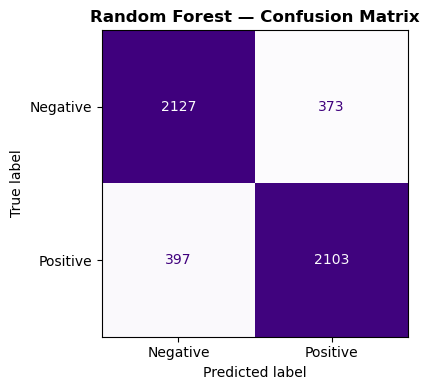

--- Random Forest: Classification Report ---
              precision    recall  f1-score   support

    Negative       0.84      0.85      0.85      2500
    Positive       0.85      0.84      0.85      2500

    accuracy                           0.85      5000
   macro avg       0.85      0.85      0.85      5000
weighted avg       0.85      0.85      0.85      5000



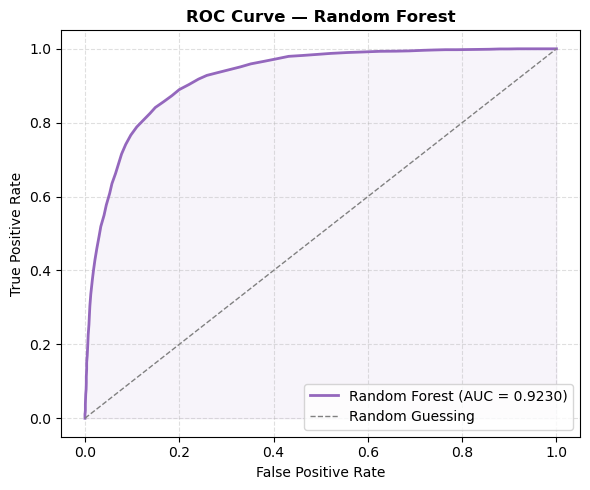

AUC: 0.9230


In [12]:
# --- CONFUSION MATRIX ---
cm_rf = confusion_matrix(y_test, y_pred_rf)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm_rf, display_labels=['Negative','Positive']).plot(
    ax=ax, colorbar=False, cmap='Purples')
ax.set_title('Random Forest — Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

# --- CLASSIFICATION REPORT ---
print("--- Random Forest: Classification Report ---")
print(classification_report(y_test, y_pred_rf, target_names=['Negative','Positive']))

# --- ROC CURVE ---
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)

plt.figure(figsize=(6, 5))
plt.plot(fpr_rf, tpr_rf, color='#9467bd', lw=2, label=f'Random Forest (AUC = {auc_rf:.4f})')
plt.plot([0,1],[0,1],'--', color='gray', lw=1, label='Random Guessing')
plt.fill_between(fpr_rf, tpr_rf, alpha=0.07, color='#9467bd')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Random Forest', fontweight='bold')
plt.legend(loc='lower right'); plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()
print(f"AUC: {auc_rf:.4f}")

### Section 7 Summary

We brought Random Forest into this lineup as the deliberate underdog, and it performed exactly like a marathon runner trying to compete in the 100-meter dash. While Random Forest has the endurance to outclass linear models on complex, non-linear terrain, the tables are completely turned here. Text classification using TF-IDF features is a straight-line sprint—a linear problem at its core—and the tree-based models pay a hefty price in speed and efficiency when they try to force a complex strategy on a simple track.

We can think of it like this: each tree in the forest is randomly grabbing a subset of our 50,000 TF-IDF columns to find a path. But for any single review, almost all of those columns are zero. It’s a dreary environment for a marathoner to find their rhythm when 99% of the track is empty space. As a result, the Random Forest trails behind Logistic Regression and LinearSVC, though it still easily clears the pre-built baselines we started with. It's a great reminder that an algorithm's raw power doesn't matter if it isn't built for the race you're running.

---
## Section 8: Head-to-Head Comparison — All Four Models

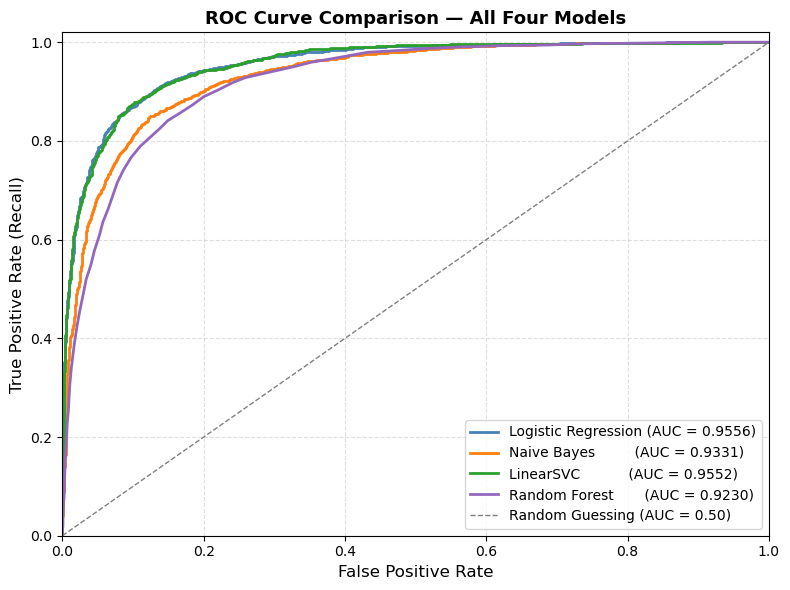

In [13]:
# --- OVERLAY ALL ROC CURVES ---
# The closer a curve hugs the top-left corner, the better.
# Plotting all four on the same axes makes the ranking immediately visible.

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr,  tpr_lr,  color='steelblue', lw=2, label=f'Logistic Regression (AUC = {auc_lr:.4f})')
plt.plot(fpr_nb,  tpr_nb,  color='#ff7f0e',   lw=2, label=f'Naive Bayes         (AUC = {auc_nb:.4f})')
plt.plot(fpr_svc, tpr_svc, color='#2ca02c',   lw=2, label=f'LinearSVC           (AUC = {auc_svc:.4f})')
plt.plot(fpr_rf,  tpr_rf,  color='#9467bd',   lw=2, label=f'Random Forest       (AUC = {auc_rf:.4f})')
plt.plot([0,1],[0,1], '--', color='gray', lw=1, label='Random Guessing (AUC = 0.50)')
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.02])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curve Comparison — All Four Models', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [14]:
# --- FULL COMPARISON TABLE ---
# Includes the Week 3 pre-built baselines for context.

results = pd.DataFrame({
    'Model': [
        'TextBlob (Week 3 baseline)',
        'VADER   (Week 3 baseline)',
        'Logistic Regression  (Ch.16)',
        'Naive Bayes          (Ch.18)',
        'LinearSVC            (Ch.17)',
        'Random Forest        (Ch.14)'
    ],
    'Accuracy': [
        '68.52%', '69.36%',
        f'{lr_acc*100:.2f}%',
        f'{nb_acc*100:.2f}%',
        f'{svc_acc*100:.2f}%',
        f'{rf_acc*100:.2f}%'
    ],
    'Precision': [
        'N/A', 'N/A',
        f"{precision_score(y_test, y_pred_lr):.4f}",
        f"{precision_score(y_test, y_pred_nb):.4f}",
        f"{precision_score(y_test, y_pred_svc):.4f}",
        f"{precision_score(y_test, y_pred_rf):.4f}"
    ],
    'Recall': [
        'N/A', 'N/A',
        f"{recall_score(y_test, y_pred_lr):.4f}",
        f"{recall_score(y_test, y_pred_nb):.4f}",
        f"{recall_score(y_test, y_pred_svc):.4f}",
        f"{recall_score(y_test, y_pred_rf):.4f}"
    ],
    'F1-Score': [
        'N/A', 'N/A',
        f"{f1_score(y_test, y_pred_lr):.4f}",
        f"{f1_score(y_test, y_pred_nb):.4f}",
        f"{f1_score(y_test, y_pred_svc):.4f}",
        f"{f1_score(y_test, y_pred_rf):.4f}"
    ],
    'AUC': [
        'N/A', 'N/A',
        f'{auc_lr:.4f}',
        f'{auc_nb:.4f}',
        f'{auc_svc:.4f}',
        f'{auc_rf:.4f}'
    ]
})

print("--- Full Model Comparison (all metrics) ---")
display(results)

--- Full Model Comparison (all metrics) ---


,Model,Accuracy,Precision,Recall,F1-Score,AUC
0,TextBlob (Week 3 baseline),68.52%,N/A,N/A,N/A,N/A
1,VADER (Week 3 baseline),69.36%,N/A,N/A,N/A,N/A
2,Logistic Regression (Ch.16),88.62%,0.8764,0.8992,0.8877,0.9556
3,Naive Bayes (Ch.18),86.06%,0.8654,0.8540,0.8597,0.9331
4,LinearSVC (Ch.17),88.50%,0.8773,0.8952,0.8862,0.9552
5,Random Forest (Ch.14),84.60%,0.8494,0.8412,0.8453,0.9230


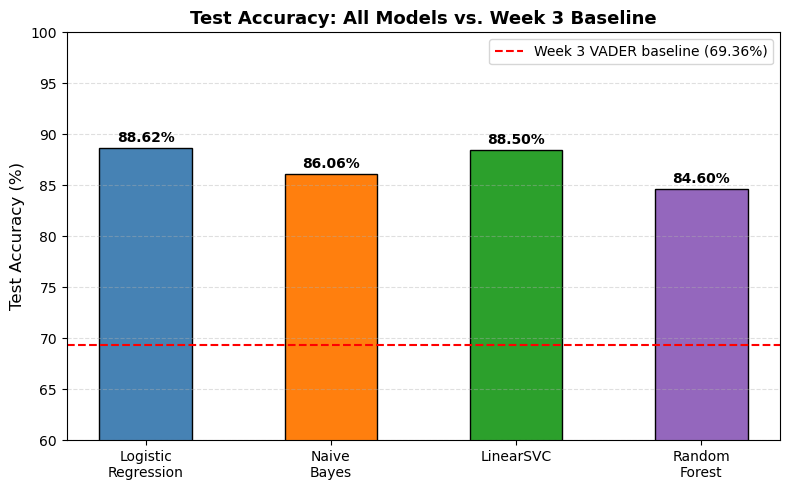

In [15]:
# --- ACCURACY BAR CHART ---
# Visual comparison of test accuracy across all four custom models
# with the pre-built baseline drawn as a reference line.

model_names = ['Logistic\nRegression', 'Naive\nBayes', 'LinearSVC', 'Random\nForest']
accuracies  = [lr_acc, nb_acc, svc_acc, rf_acc]
colors      = ['steelblue', '#ff7f0e', '#2ca02c', '#9467bd']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(model_names, [a*100 for a in accuracies], color=colors, edgecolor='black', width=0.5)

# Add value labels on each bar
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{acc*100:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Reference line for Week 3 VADER baseline
ax.axhline(y=69.36, color='red', linestyle='--', lw=1.5, label='Week 3 VADER baseline (69.36%)')
ax.set_ylim([60, 100])
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Test Accuracy: All Models vs. Week 3 Baseline',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

---
## Conclusion

All that groundwork we put in with the previous week really paid off and made it pretty easy to conclude that domain-specific training is pretty important.

Every single custom model we trained left those previous pre-built baselines in the dust. TextBlob and VADER hit a wall at about 69% accuracy because they rely on generic lexicons that have no idea how film critics actually write. By training directly on 20,000 movie reviews, our models learned the language of the domain. So, once we armed our models with the sarcasm, the dramatic hyperbole, and the cinematic jargon, we were handsomely rewarded with a massive jump in accuracy.

When we take a look at the final rankings, the story is all about matching the algorithm to the data structure. LinearSVC and Logistic Regression led the pack because they are linear classifiers built to handle massive, sparse TF-IDF matrices. Naive Bayes held its own as the lightning-fast, transparent alternative. Unfortunately for Random Forest this time around, the struggle was indeed very real. It turns out that forcing a tree model to chew through 50,000 mostly-zero columns per row is a tough ask.

From a methodology standpoint, dodging data leakage in Section 3 was a move that really shines now that all is said and done. Fitting our vectorizer strictly on the training data wasn't just a technicality; it's really the only reason we can actually trust these results. Every metric in this notebook reflects how these models handle genuinely unseen data, completely free of those "rose-colored glasses."

So, where do we go from here? If we wanted to squeeze out even more accuracy, we could look into n-grams (grouping two or three words together so we don't lose phrase context), tune our regularization parameters, or even jump into neural word embeddings to capture the actual semantic meaning behind the text. But all in all, this is a pretty decent result from a meager baseline TF-IDF setup.